<a href="https://colab.research.google.com/github/AdityaWarrier2006/TensorFlow-for-Machine-Learning/blob/main/01_02_neural_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print(tf.__version__)

2.20.0


In [2]:
x = tf.range(-200,200,7) # creates a tensor
x = tf.expand_dims(x, axis = -1)
y = x + 15

len(x), len(y)

(58, 58)

In [3]:
# split the data
x_train = x[:46] # first 46
y_train = y[:46]

x_test = x[46:] # last 12
y_test = y[46:]

len(x_train),len(y_train), len(x_test), len(y_test)

(46, 46, 12, 12)

In [4]:
# our earlier plot function
def plot_predictions(train_data,
                     train_labels,
                     test_data,
                     test_labels,
                     pred):
  plt.figure(figsize=(10,7))
  # plot trainng data in blue
  plt.scatter(train_data, train_labels, c = 'b', label = "Training Data")
  # plot test data in green
  plt.scatter(test_data, test_labels, c = 'g', label = "Testing Data")
  # plot predictions in red
  plt.scatter(test_data, pred, c = 'r', label = "Predictions")
  # show legend
  plt.legend();

In [5]:
# make functions to use mae and mse
def mae(y_test, y_pred):
  return tf.keras.losses.MAE(y_test, y_pred)

def mse(y_test, y_pred):
  return tf.keras.losses.MSE(y_test, y_pred)

In [6]:
'''
3 experiments-

1. model_1 - same as og model
2. model_2 - 2 layers, 100 epochs
3. model_3 - 2 layers, 500 epochs
4. model_4 - 2 layers, 100 epochs, Adam optimizer
''';

Model_1

In [7]:
# same as og model

model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape = [1])
    ])
model_1.compile(loss = ["mae"],
                optimizer = tf.keras.optimizers.SGD(),
                metrics = ["mae"])
model_1.fit(x_train, y_train, epochs = 100, verbose = 0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
y_pred_1 = model_1.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


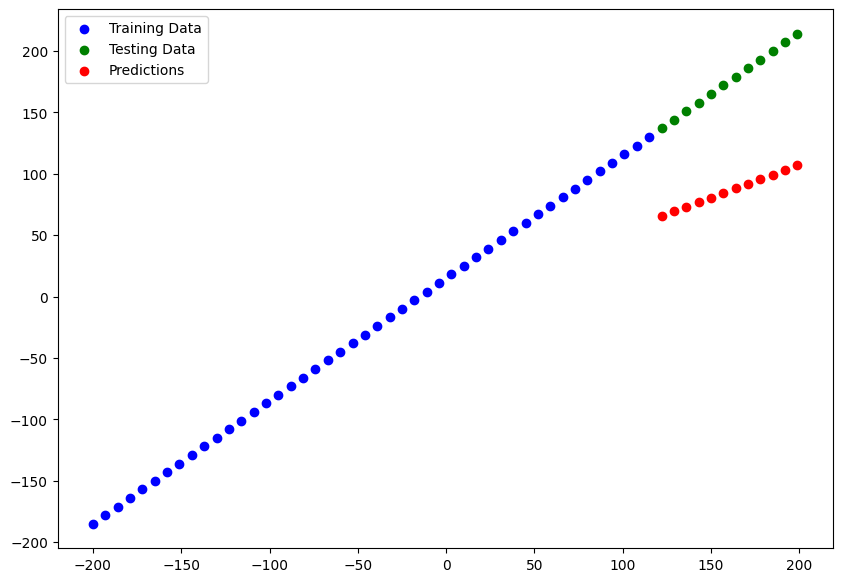

In [9]:
plot_predictions(x_train, y_train, x_test, y_test, y_pred_1)


In [10]:
mae_1 = mae(tf.squeeze(y_test), tf.squeeze(y_pred_1))
mse_1 = mse(tf.squeeze(y_test), tf.squeeze(y_pred_1))
mae_1, mse_1

(<tf.Tensor: shape=(), dtype=float32, numpy=89.26981353759766>,
 <tf.Tensor: shape=(), dtype=float32, numpy=8096.32177734375>)

Model_2

In [11]:
# 2 layers, 100 epochs

model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(10, input_shape = [1]),
    tf.keras.layers.Dense(1)
    ])
model_2.compile(loss = ["mae"],
                optimizer = tf.keras.optimizers.SGD(),
                metrics = ["mae"])
model_2.fit(x_train, y_train, epochs = 100, verbose = 0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
y_pred_2 = model_2.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step


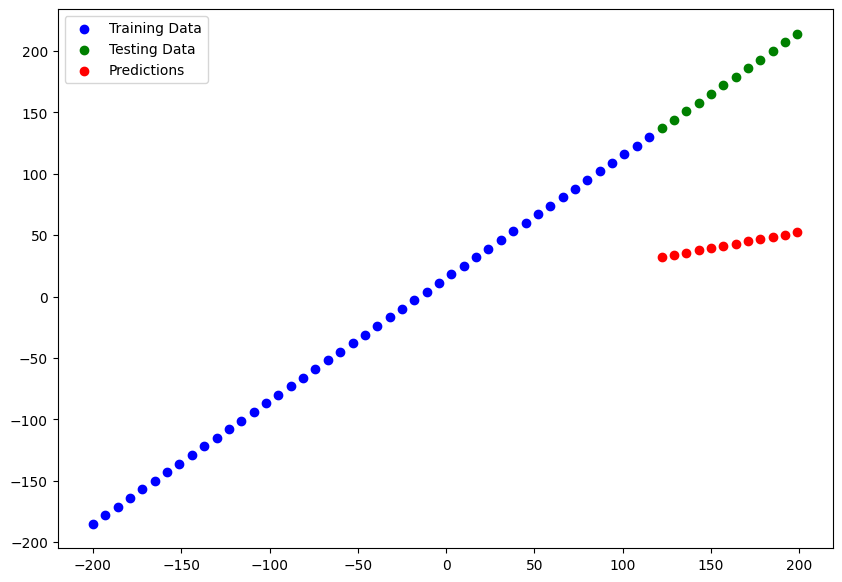

In [13]:
plot_predictions(x_train, y_train, x_test, y_test, y_pred_2)


In [14]:
mae_2 = mae(tf.squeeze(y_test), tf.squeeze(y_pred_2))
mse_2 = mse(tf.squeeze(y_test), tf.squeeze(y_pred_2))
mae_2, mse_2

(<tf.Tensor: shape=(), dtype=float32, numpy=133.35340881347656>,
 <tf.Tensor: shape=(), dtype=float32, numpy=18100.876953125>)

Model_3

In [15]:
# 2 layers, 500 epochs

model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(10, input_shape=[1]),
    tf.keras.layers.Dense(1)
])

model_3.compile(loss = ["mae"],
                optimizer = tf.keras.optimizers.SGD(),
                metrics = ["mae"])

model_3.fit(x_train, y_train, epochs = 500, verbose = 0)

In [16]:
y_pred_3 = model_3.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step


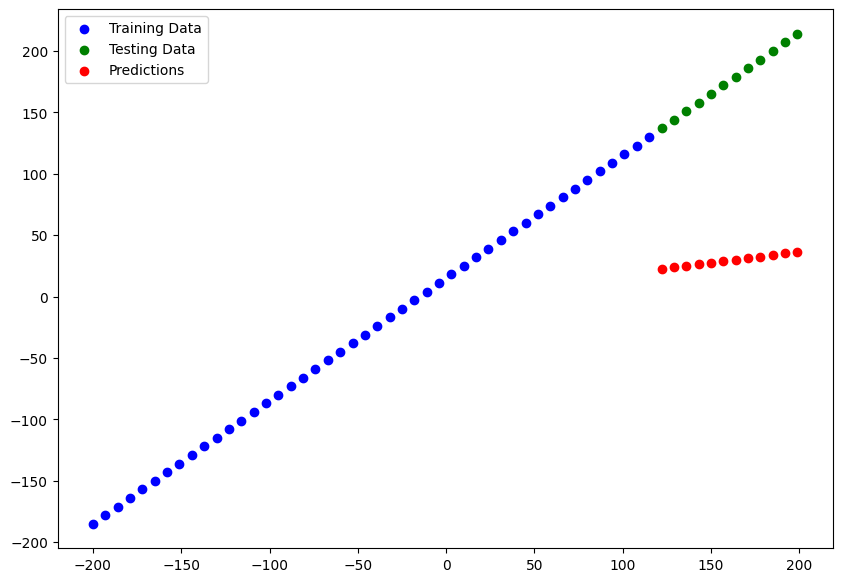

In [17]:
plot_predictions(x_train, y_train, x_test, y_test, y_pred_3)


In [18]:
mae_3 = mae(tf.squeeze(y_test), tf.squeeze(y_pred_3))
mse_3 = mse(tf.squeeze(y_test), tf.squeeze(y_pred_3))
mae_3, mse_3

(<tf.Tensor: shape=(), dtype=float32, numpy=146.0059814453125>,
 <tf.Tensor: shape=(), dtype=float32, numpy=21711.365234375>)

Model_4

In [19]:
# 2 layers, 100 epochs, Adam optimizer

model_4 = tf.keras.Sequential([
    tf.keras.layers.Dense(10, input_shape=[1]),
    tf.keras.layers.Dense(1)
])

model_4.compile(loss = ["mae"],
                optimizer = tf.keras.optimizers.Adam(learning_rate = 0.01),
                metrics = ["mae"])

model_4.fit(x_train, y_train, epochs = 100, verbose = 0)

In [20]:
y_pred_4 = model_4.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step


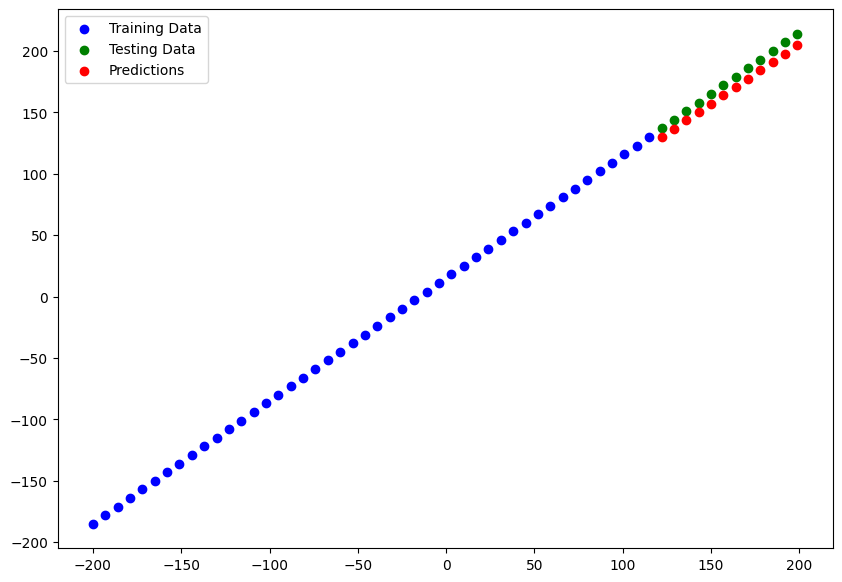

In [21]:
plot_predictions(x_train, y_train, x_test, y_test, y_pred_4)


In [22]:
mae_4 = mae(tf.squeeze(y_test), tf.squeeze(y_pred_4))
mse_4 = mse(tf.squeeze(y_test), tf.squeeze(y_pred_4))
mae_4, mse_4 # most accurate so far

(<tf.Tensor: shape=(), dtype=float32, numpy=8.257351875305176>,
 <tf.Tensor: shape=(), dtype=float32, numpy=68.82234191894531>)

Comparing our Models

In [23]:
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (20.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [24]:
model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (136.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [25]:
model_3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (136.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [26]:
model_4.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95 (384.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 64 (260.00 B)

In [27]:
# let's compare our models's results using a pandas DataFrame
import pandas as pd

In [28]:
model_results = [["model_1", mae_1.numpy(), mse_1.numpy()],
                 ["model_2", mae_2.numpy(), mse_2.numpy()],
                 ["model_3", mae_3.numpy(), mse_3.numpy()],
                 ["model_4", mae_4.numpy(), mse_4.numpy()]]
all_results = pd.DataFrame(model_results, columns = ["model", "mae", "mse"])
all_results

,model,mae,mse
0,model_1,89.269814,8096.321777
1,model_2,133.353409,18100.876953
2,model_3,146.005981,21711.365234
3,model_4,8.257352,68.822342


In [29]:
# saving our models allows us to use them outside google colabs

'''
Main formats
1. SavedModel
2. HDF5
''';
model_4.save("best_model_SavedModel_format.keras")
model_4.save("best_model_HDF5_format.h5")

Loading in a model

In [30]:
# load in SavedModel
loaded_SavedModel_format = tf.keras.models.load_model("/content/best_model_SavedModel_format.keras")
loaded_SavedModel_format.summary() == model_4.summary() # verify it is the same

# compare model_4 prediction with SavedModel predictions
y_pred_test = model_4.predict(x_test)
y_pred_SavedModel = loaded_SavedModel_format.predict(x_test)

y_pred_test == y_pred_SavedModel

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95 (384.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

...

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 64 (260.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step


array([[ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True]])